# EDA Project

#### RELIANCE DIGITAL STORE

#### 1) Data Understanding problem / statement

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
customers=pd.read_csv('messy_customers.csv')
order_item=pd.read_csv('messy_order_items.csv')
orders=pd.read_csv('messy_orders.csv')
products=pd.read_csv('messy_products.csv')

In [80]:
customers

,customer_id,customer_name,city,signup_date
0,C0001,Customer_1,DELHI,2024-02-09
1,C0002,Customer_2,delhi,2025-04-20
2,C0003,Customer_3,Bangalore,2024-08-19
3,C0004,Customer_4,Pune,2023-08-08
4,C0005,NaN,Bengaluru,2024-03-04
...,...,...,...,...
515,C0391,Customer_391,Kolkata,2023-01-07
516,C0483,Customer_483,Delhi,2023-02-25
517,C0473,Customer_473,Bangalore,2023-12-05
518,C0417,Customer_417,Bangalore,2025-01-24


I have data of 520 customers with having unique ID, name , city and their signup date

In [81]:
customers[customers.duplicated(keep=False)]

,customer_id,customer_name,city,signup_date
13,C0014,Customer_14,delhi,2024-08-18
32,C0033,Customer_33,mumbai,2024-04-30
132,C0133,Customer_133,Mumbai,2025-05-10
155,C0156,Customer_156,Pune,2024-08-07
179,C0180,Customer_180,NaN,2025-01-16
217,C0218,Customer_218,delhi,2025-02-02
221,C0222,Customer_222,Hyderabad,2024-05-20
249,C0250,Customer_250,Mumbai,2024-12-31
293,C0294,Customer_294,Hyderabad,2023-09-12
302,C0303,Customer_303,Kolkata,2024-03-23


Customers table also have duplicate values so i have to delete it in order to make analysis process better

In [82]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    520 non-null    str  
 1   customer_name  492 non-null    str  
 2   city           479 non-null    str  
 3   signup_date    520 non-null    str  
dtypes: str(4)
memory usage: 16.4 KB


In customers table there is a column with name signup_date which is not in proper format so i have to convert it into pandas date time format and also in column customer_name and city there is null values also found

In [83]:
customers.describe()

,customer_id,customer_name,city,signup_date
count,520,492,479,520
unique,500,472,11,379
top,C0014,Customer_14,Hyderabad,2023-06-15
freq,2,2,54,4


It gives me the short description of the table in which it gives counting of the values in column and unique values found in that column  

In [84]:
order_item

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.0,NaN
1,2,O00857,P010,1.0,NaN
2,3,O00589,P007,2.0,77415.0
3,4,O00112,P045,2.0,49066.0
4,5,O00322,P036,2.0,58380.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


I have data of 2050 order item with having order item ID, order ID , product ID , quantity and their unit price

In [85]:
order_item[order_item.duplicated]

,order_item_id,order_id,product_id,quantity,unit_price
2000,689,O01021,P004,0.0,NaN
2001,436,O00386,P012,3.0,31320.0
2002,1596,O00176,P065,1.0,NaN
2003,1775,O00896,P030,3.0,40678.0
2004,1904,O00312,P031,3.0,NaN
2005,1420,O00327,P039,2.0,53326.0
2006,411,O01054,P072,0.0,85189.0
2007,697,O00355,P063,4.0,55126.0
2008,1006,O00750,P041,0.0,NaN
2009,861,O00205,P060,4.0,55826.0


Order Item table also have duplicate values so i have to delete it in order to make analysis process better

In [86]:
order_item.info()

<class 'pandas.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2050 non-null   int64  
 1   order_id       2050 non-null   str    
 2   product_id     2050 non-null   str    
 3   quantity       1732 non-null   float64
 4   unit_price     1039 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 80.2 KB


In this table we have a column with name quantity which is not in proper format so we have to convert it into proper format and also we have null  values in quantity and unit price column.

In [87]:
order_item.describe()

,order_item_id,quantity,unit_price
count,2050.000000,1732.000000,1039.000000
mean,999.866341,1.991339,44956.006737
std,576.435038,1.411120,24978.977806
min,1.000000,0.000000,1072.000000
25%,502.250000,1.000000,23987.000000
50%,998.500000,2.000000,43654.000000
75%,1499.750000,3.000000,65136.500000
max,2000.000000,4.000000,89980.000000


It gives me the counting of the values found in columns and also gives mean, standard deviation, minimum, 25% percentile, 50% percentile,75% percentile and maximum of the columns.

In [88]:
orders

,order_id,customer_id,order_date,payment_method
0,O00001,C0058,09/05/2024,Cash on Delivery
1,O00002,C0410,2024-02-01,upi
2,O00003,C0429,13/04/2025,Cash
3,O00004,C0272,2024-02-25,Debit Card
4,O00005,C0411,04-26-2025,credit card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


I have data of 1240 orders with having order ID , customer ID , order date and their payment method.

In [89]:
orders[orders.duplicated(keep=False)]

,order_id,customer_id,order_date,payment_method
14,O00015,C0329,02/09/2024,Cash on Delivery
71,O00072,C0033,2024-01-06,UPI
116,O00117,C0061,04-07-2025,UPI
127,O00128,C0383,03-31-2025,Credit Card
140,O00141,C0217,13/10/2024,Debit Card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


Orders table also have duplicate values so i have to delete it in order to make analysis process better.

In [90]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        1240 non-null   str  
 1   customer_id     1240 non-null   str  
 2   order_date      1240 non-null   str  
 3   payment_method  1095 non-null   str  
dtypes: str(4)
memory usage: 38.9 KB


In orders table there is a column with name order_date which is not in proper format so i have to convert it into pandas date time format and also in column payment_method there is null values also found.

In [91]:
orders.describe()

,order_id,customer_id,order_date,payment_method
count,1240,1240,1240,1095
unique,1200,448,815,7
top,O00015,C0218,2024-02-21,Credit Card
freq,2,10,5,171


It gives the counting of the values in column and unique values found in that column and also give top values and frequency of the top values

In [92]:
products

,product_id,product_name,category,base_price
0,P001,Lenovo IdeaPad,Tablet,28151.0
1,P002,Samsung Tab,Smartphone,68660.0
2,P003,HP Pavilion,Accessories,NaN
3,P004,Lenovo Tab,tablet,NaN
4,P005,OnePlus,Tablet,NaN
...,...,...,...,...
85,P022,Samsung Tab,Accessory,NaN
86,P052,Xiaomi Redmi,smart phone,NaN
87,P010,iPhone 13,smart phone,NaN
88,P059,OnePlus,Accessories,NaN


I have data of 90 products with having product ID , product name , category and there base price.

In [93]:
products[products.duplicated(keep=False)]

,product_id,product_name,category,base_price
9,P010,iPhone 13,smart phone,NaN
16,P017,Keyboard,Smartphone,NaN
19,P020,Dell Inspiron,Smartphone,NaN
21,P022,Samsung Tab,Accessory,NaN
32,P033,Wireless Mouse,laptop,47453.0
51,P052,Xiaomi Redmi,smart phone,NaN
58,P059,OnePlus,Accessories,NaN
61,P062,Dell Inspiron,Tablet,NaN
71,P072,Dell Inspiron,Tablet,NaN
75,P076,Wireless Mouse,Accessory,15249.0


Products table also have duplicate values so i have to delete it in order to make analysis process better.

In [94]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    90 non-null     str    
 1   product_name  90 non-null     str    
 2   category      90 non-null     str    
 3   base_price    33 non-null     float64
dtypes: float64(1), str(3)
memory usage: 2.9 KB


In products table null values found in base price column.

In [95]:
products.describe()

,base_price
count,33.000000
mean,45047.454545
std,25654.215131
min,2571.000000
25%,27157.000000
50%,47453.000000
75%,68660.000000
max,84776.000000


It gives counting of values, mean, standard deviation, minimum, 25% percentile, 50% percentile,75% percentile and maximum of the base price column.

#### 2) Pre-processing data

In [96]:
customers.drop_duplicates(inplace=True)

In [97]:
order_item.drop_duplicates(inplace=True)

In [98]:
orders.drop_duplicates(inplace=True)

In [99]:
products.drop_duplicates(inplace=True)

Duplicate values in tables are now deleted

In [100]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

Signup date column in customers table now in proper pandas date time format

In [101]:
orders['order_date'] = pd.to_datetime(orders['order_date'],format='mixed')

order_date in orders table are in mixed format so we use format function.

#### 3) Handling Inconsistant Data

In [102]:
customers['city'] = customers['city'].str.title()

str is a module of pandas which operates string values and with the help title function first letter is capital and other are small.

In [103]:
customers['city']=customers['city'].replace({'Bangalore':'Bengaluru'}).copy()

By using replace function we handle inconsistant values in city

In [104]:
products['category']=products['category'].str.title()
products['category']=products['category'].replace({"Accessory":"Accessories","Smart Phone":"Smartphone"})

By using replace function we handle inconsistant values in category column

In [105]:
orders['payment_method']=orders['payment_method'].str.title()
orders['payment_method']=orders['payment_method'].replace({"Cash On Delivery":"Cash"})

By using replace function we handle inconsistant values in payment_method column

#### 4) Handling missing values

In [106]:
orders['payment_method']=orders['payment_method'].ffill().copy()

I fill payment method's null values by using forward fill function and we pass a copy of that column. 

In [107]:
customers['city']=customers['city'].bfill().copy()

I fill city's null values by using backward fill function and we pass a copy of that column.

In [108]:
order_item['unit_price']=order_item['unit_price'].fillna(order_item['product_id'].map(products.set_index('product_id')['base_price']))

Fill missing values in unit_price are imputed by mapping each product_id to its corresponding base_price from the products dataset. 

In [109]:
order_item.fillna({'quantity':order_item['quantity'].mean(),'unit_price':order_item['unit_price'].mean()},inplace=True)

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.000000,47453.000000
1,2,O00857,P010,1.000000,45038.245702
2,3,O00589,P007,2.000000,77415.000000
3,4,O00112,P045,2.000000,49066.000000
4,5,O00322,P036,2.000000,58380.000000
...,...,...,...,...,...
1995,1996,O00944,P007,4.000000,64106.000000
1996,1997,O00629,P017,4.000000,45038.245702
1997,1998,O00703,P008,0.000000,76524.000000
1998,1999,O01083,P043,3.000000,18251.000000


Rest of the missing values in unit_price and quantity column are fill by using mean

In [110]:
order_item['quantity'] = order_item['quantity'].astype('int')

convert datatype of quantity column to integer

#### 5) Merging Data

In [111]:
first = order_item.merge(products,on='product_id',how='outer')

In [112]:
second = orders.merge(customers,on='customer_id',how='outer')

In [113]:
df = first.merge(second,on='order_id',how='inner')

In [114]:
df

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date
0,228,O00862,P001,1,30940.0,Lenovo IdeaPad,Tablet,28151.0,C0246,2024-09-24,Cash,Customer_246,Mumbai,2025-01-14
1,427,O00610,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0233,2024-10-23,Upi,Customer_233,Hyderabad,2025-02-24
2,618,O00343,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0009,2024-07-02,Debit Card,Customer_9,Delhi,2024-08-13
3,634,O00485,P001,1,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0370,2024-01-24,Credit Card,Customer_370,Mumbai,2023-04-09
4,662,O01127,P001,1,34936.0,Lenovo IdeaPad,Tablet,28151.0,C0168,2025-04-09,Credit Card,Customer_168,Delhi,2023-07-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1662,O01122,P080,1,82478.0,OnePlus,Laptop,82478.0,C0084,2025-03-11,Credit Card,Customer_84,Mumbai,2023-01-30
1996,1695,O00412,P080,2,82478.0,OnePlus,Laptop,82478.0,C0217,2024-03-27,Upi,Customer_217,Pune,2023-04-05
1997,1814,O00575,P080,0,80491.0,OnePlus,Laptop,82478.0,C0213,2024-10-01,Cash,Customer_213,Pune,2023-02-21
1998,1872,O00288,P080,2,82478.0,OnePlus,Laptop,82478.0,C0253,2024-07-25,Credit Card,Customer_253,Chennai,2023-03-20


This is my final data where over all information according to all four table has been included

#### 6) Transform Data/ Feature Engineering

In [115]:
df['Amount']=df['quantity']*df['unit_price']

In [116]:
df['year'] = df['order_date'].dt.year

In [117]:
df['month'] = df['order_date'].dt.month_name()

In [118]:
df

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date,Amount,year,month
0,228,O00862,P001,1,30940.0,Lenovo IdeaPad,Tablet,28151.0,C0246,2024-09-24,Cash,Customer_246,Mumbai,2025-01-14,30940.0,2024,September
1,427,O00610,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0233,2024-10-23,Upi,Customer_233,Hyderabad,2025-02-24,112604.0,2024,October
2,618,O00343,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0009,2024-07-02,Debit Card,Customer_9,Delhi,2024-08-13,112604.0,2024,July
3,634,O00485,P001,1,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0370,2024-01-24,Credit Card,Customer_370,Mumbai,2023-04-09,28151.0,2024,January
4,662,O01127,P001,1,34936.0,Lenovo IdeaPad,Tablet,28151.0,C0168,2025-04-09,Credit Card,Customer_168,Delhi,2023-07-26,34936.0,2025,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1662,O01122,P080,1,82478.0,OnePlus,Laptop,82478.0,C0084,2025-03-11,Credit Card,Customer_84,Mumbai,2023-01-30,82478.0,2025,March
1996,1695,O00412,P080,2,82478.0,OnePlus,Laptop,82478.0,C0217,2024-03-27,Upi,Customer_217,Pune,2023-04-05,164956.0,2024,March
1997,1814,O00575,P080,0,80491.0,OnePlus,Laptop,82478.0,C0213,2024-10-01,Cash,Customer_213,Pune,2023-02-21,0.0,2024,October
1998,1872,O00288,P080,2,82478.0,OnePlus,Laptop,82478.0,C0253,2024-07-25,Credit Card,Customer_253,Chennai,2023-03-20,164956.0,2024,July


#### 7) Exploring Data & Visualization

In [119]:
#total Revenue
total_revenue=df['Amount'].sum()
print(f"₹{int(total_revenue)}")

₹165023180


In [152]:
#total quantity sold
total_qty_sold = df['quantity'].sum()
print(total_qty_sold)

3685


In [120]:
#revenue by month
monthly_sales = df.groupby('month')['Amount'].sum().astype('int')
print(monthly_sales.sort_values(ascending=False))

month
January      22296015
April        21569575
March        20284421
February     17330222
May          14990969
June         11699719
December     10593763
July          9962422
October       9663569
November      9550624
September     8952460
August        8129417
Name: Amount, dtype: int64


Text(0, 0.5, 'REVENUE')

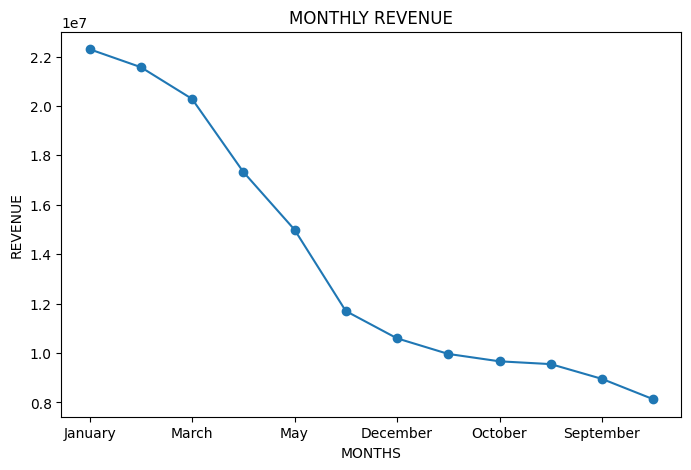

In [156]:
plt.figure(figsize=(8,5))
monthly_sales.sort_values(ascending=False).plot(kind='line',marker='o')
plt.title('MONTHLY REVENUE')
plt.xlabel('MONTHS')
plt.ylabel('REVENUE')

January month has maximum number of sales and and august month has minimum number of sales.

In [122]:
#top_product by revenue
top_product = df.groupby('product_name')['Amount'].sum().head(5).astype('int')
top_5_prod = pd.DataFrame(top_product.sort_values(ascending=False))
top_5_prod

,Amount
product_name,
Dell Inspiron,17443441
Laptop Bag,17389637
Lenovo IdeaPad,11479789
Keyboard,8818222
HP Pavilion,6206948


Text(0, 0.5, 'REVENUE')

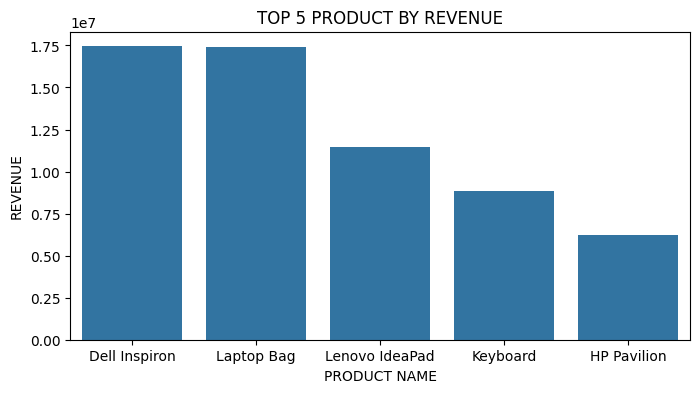

In [158]:
plt.figure(figsize=(8,4))
sns.barplot(x='product_name',y='Amount',data=top_5_prod)
plt.title('TOP 5 PRODUCT BY REVENUE')
plt.xlabel('PRODUCT NAME')
plt.ylabel('REVENUE')

Dell Inspiron and Laptop Bag are two major selling product

In [124]:
top_customer = df.groupby('customer_id')['Amount'].sum().head(5).astype('int')
top_5_cust = pd.DataFrame(top_customer.sort_values(ascending=False))
top_5_cust

,Amount
customer_id,
C0001,1089958
C0005,890416
C0003,545229
C0002,494086
C0004,60996


Text(0, 0.5, 'REVENUE')

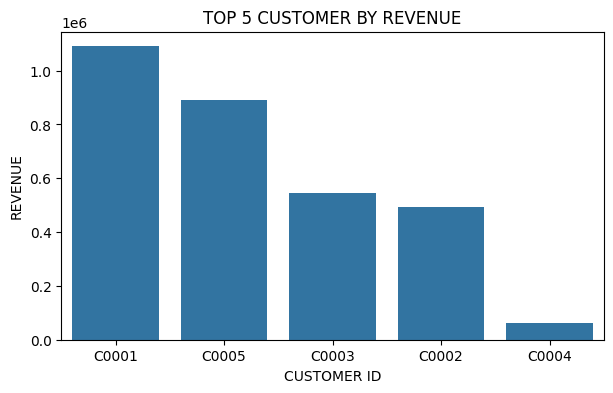

In [159]:
plt.figure(figsize=(7,4))
sns.barplot(x='customer_id',y='Amount',data=top_5_cust)
plt.title('TOP 5 CUSTOMER BY REVENUE')
plt.xlabel('CUSTOMER ID')
plt.ylabel('REVENUE')

As shown in the chart, among the top five customers, C0001 recorded the highest revenue, making them the leading contributor.

Text(0.5, 1.0, 'Correlation')

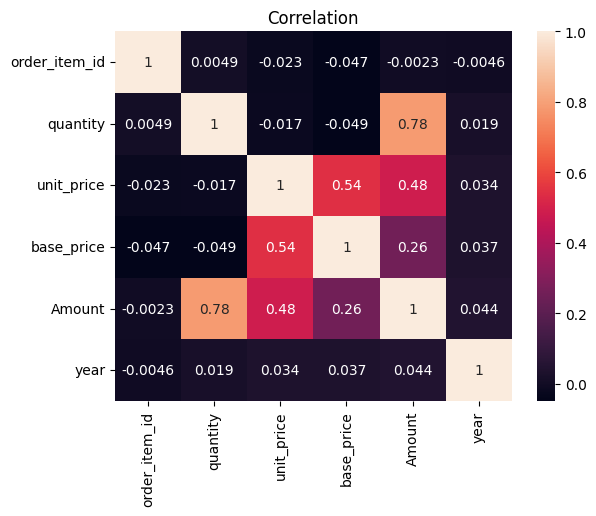

In [126]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),annot=True)
plt.title('Correlation')

There is a strong correlation (0.78) between quantity and amount. As quantity increase amount also increase.

There is a moderate correlation (0.54) between base price and unit price. Since it is positive, when the base price increases, the unit price generally tends to increases too.

In [127]:
#revenue by year
yearly_sales = df.groupby('year')['Amount'].sum().astype('int')
print(yearly_sales)

year
2024    120871668
2025     44151511
Name: Amount, dtype: int64


Text(0, 0.5, 'REVENUE')

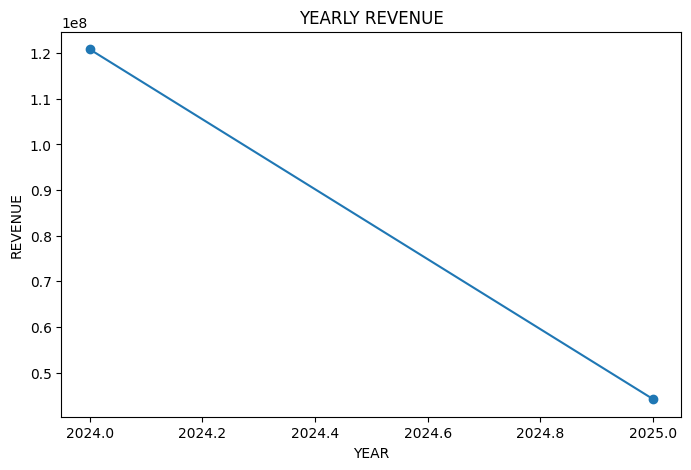

In [128]:
plt.figure(figsize=(8,5))
yearly_sales.plot(kind='line',marker='o')
plt.title('YEARLY REVENUE')
plt.xlabel('YEAR')
plt.ylabel('REVENUE')

REVENUE generate in year 2025 is lowest as compare to the previous year

In [129]:
citywise_sales = df.groupby('city')['Amount'].sum().astype('int')
city_sales = pd.DataFrame(citywise_sales.sort_values(ascending=False))
city_sales

,Amount
city,
Delhi,49714139
Mumbai,27276319
Hyderabad,23631820
Bengaluru,23559824
Pune,17009852
Kolkata,12845589
Chennai,10985636


Text(0, 0.5, 'REVENUE')

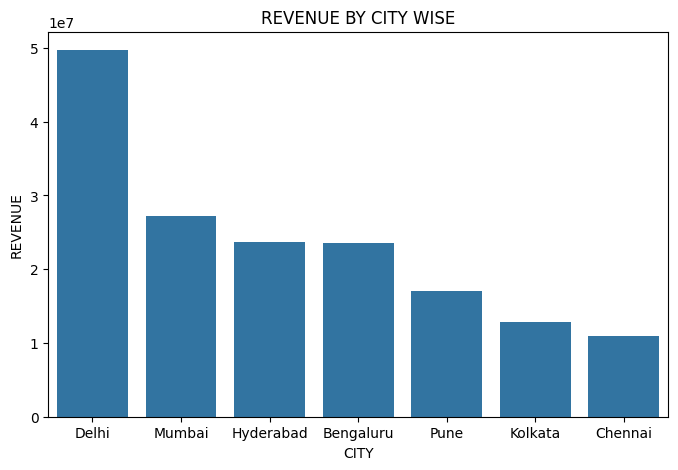

In [130]:
plt.figure(figsize=(8,5))
sns.barplot(x='city',y='Amount',data=city_sales)
plt.title('REVENUE BY CITY WISE')
plt.xlabel('CITY')
plt.ylabel('REVENUE')

As shown in chart, Delhi generates the hghest revenue 

In [131]:
category_revenue = df.groupby('category')['Amount'].sum().astype('int')
category_wise_revenue = pd.DataFrame(category_revenue.sort_values(ascending=False))
category_wise_revenue

,Amount
category,
Smartphone,53880121
Accessories,41561243
Tablet,38008154
Laptop,31573661


Text(0.5, 1.0, 'CATEGORY WISE REVENUE')

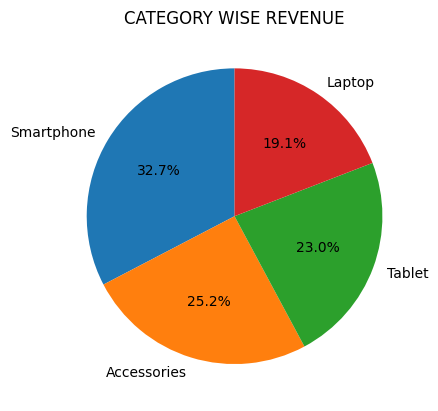

In [132]:
plt.pie(
    category_wise_revenue['Amount'],           # values
    labels=category_wise_revenue.index,        # category names
    autopct='%1.1f%%',                         # percentage show karega
    startangle=90
)
plt.title('CATEGORY WISE REVENUE')

As shown in chart, smart phone genetrates highest revenue

In [133]:
payment_methods = df.groupby('payment_method')['Amount'].sum().astype('int')
payment_wise_revenue = pd.DataFrame(payment_methods.sort_values(ascending=False))
payment_wise_revenue

,Amount
payment_method,
Cash,49578475
Upi,47240103
Credit Card,46314821
Debit Card,21889780


Text(0.5, 1.0, 'PAYMENT METHOD DISTRIBUTION')

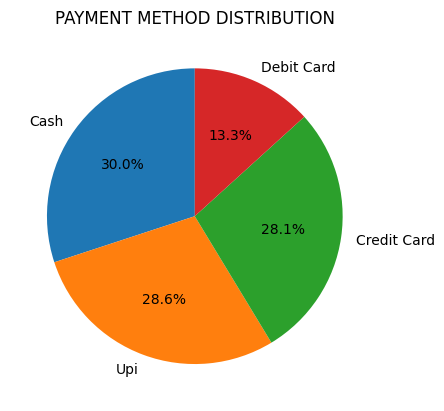

In [134]:
plt.pie(
    payment_wise_revenue['Amount'],           # values
    labels=payment_wise_revenue.index,        # category names
    autopct='%1.1f%%',                         # percentage show karega
    startangle=90
)
plt.title('PAYMENT METHOD DISTRIBUTION')

As shown in chart, most payment received in cash

In [135]:
monthly_qty_sold = df.groupby('month')['quantity'].sum()
print(monthly_qty_sold.sort_values(ascending=False))

month
January      495
April        488
March        427
February     387
May          349
December     250
June         249
July         231
November     219
October      211
September    193
August       186
Name: quantity, dtype: int64


Text(0, 0.5, 'QUANTITY')

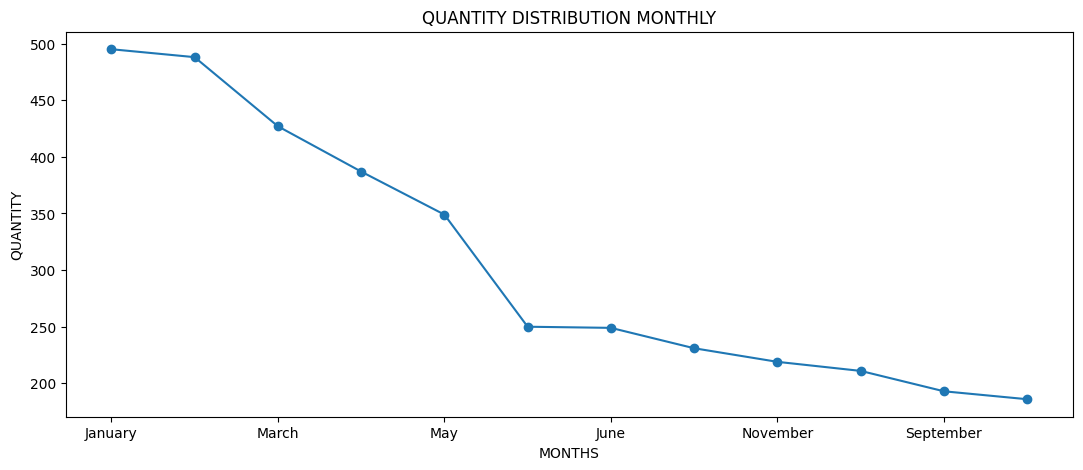

In [136]:
plt.figure(figsize=(13,5))
monthly_qty_sold.sort_values(ascending=False).plot(kind='line',marker='o')
plt.title('QUANTITY DISTRIBUTION MONTHLY')
plt.xlabel('MONTHS')
plt.ylabel('QUANTITY')

As above figure we can see that highest quantity sold in january month

In [137]:
citywise_qty = df.groupby('city')['quantity'].sum()
city_qty = pd.DataFrame(citywise_qty.sort_values(ascending=False))
city_qty

,quantity
city,
Delhi,1100
Mumbai,638
Bengaluru,550
Hyderabad,512
Pune,376
Kolkata,277
Chennai,232


Text(0, 0.5, 'QUANTITY')

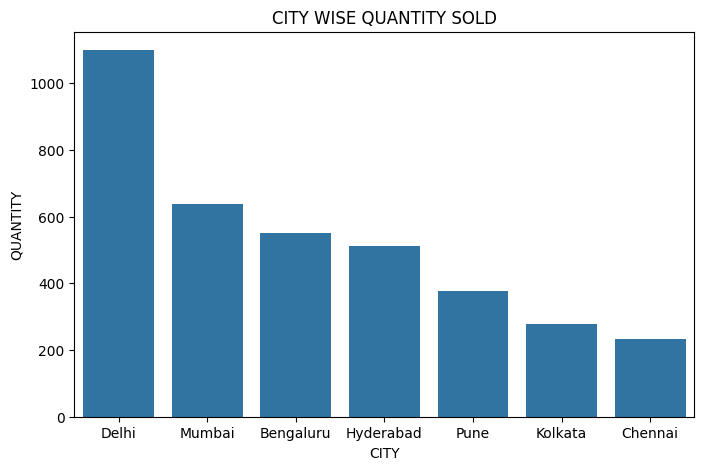

In [138]:
plt.figure(figsize=(8,5))
sns.barplot(x='city',y='quantity',data=city_qty)
plt.title('CITY WISE QUANTITY SOLD')
plt.xlabel('CITY')
plt.ylabel('QUANTITY')

Delhi has the highest quantity sold while Chennai has least quantity sold

In [139]:
top_product_sold = df.groupby('product_name')['quantity'].sum().head(5)
top_5_product = pd.DataFrame(top_product_sold.sort_values(ascending=False))
top_5_product

,quantity
product_name,
Dell Inspiron,361
Laptop Bag,354
Lenovo IdeaPad,262
Keyboard,205
HP Pavilion,137


Text(0, 0.5, 'QUANTITY')

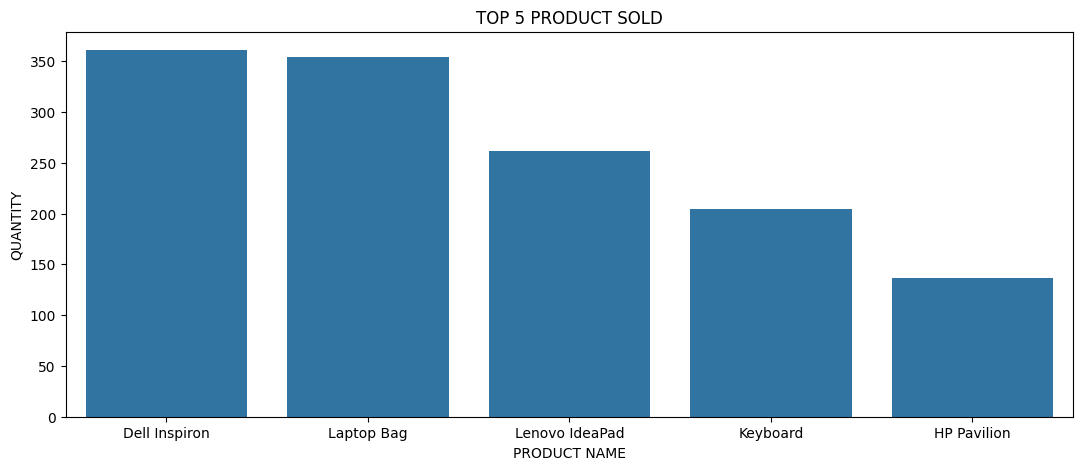

In [140]:
plt.figure(figsize=(13,5))
sns.barplot(x='product_name',y='quantity',data=top_5_product)
plt.title('TOP 5 PRODUCT SOLD')
plt.xlabel('PRODUCT NAME')
plt.ylabel('QUANTITY')

Dell Inspiron has highest sold product  

In [141]:
pay_methods = df.groupby('payment_method')['quantity'].sum()
pay = pd.DataFrame(pay_methods.sort_values(ascending=False))
pay

,quantity
payment_method,
Cash,1083
Credit Card,1066
Upi,1035
Debit Card,501


Text(0.5, 1.0, 'PAYMENT METHOD DISTRIBUTION')

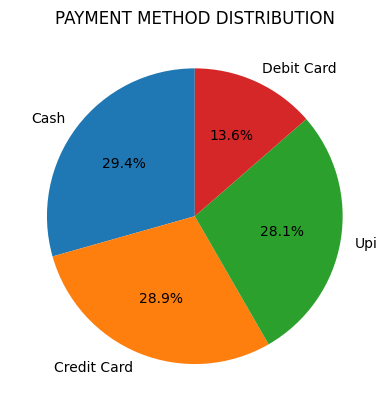

In [142]:
plt.pie(
    pay['quantity'],           # values
    labels=pay.index,        # category names
    autopct='%1.1f%%',         # percentage show karega
    startangle=90
)
plt.title('PAYMENT METHOD DISTRIBUTION')

Alomost 30% Quantity of product are sold in cash on delivery

In [143]:
category_qty = df.groupby('category')['quantity'].sum()
category_wise_qty = pd.DataFrame(category_qty.sort_values(ascending=False))
category_wise_qty

,quantity
category,
Smartphone,1187
Accessories,938
Tablet,852
Laptop,708


Text(0.5, 1.0, 'CATEGORY WISE QUANTITY SOLD')

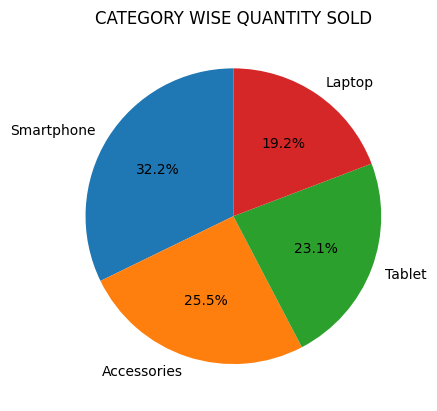

In [144]:
plt.pie(
    category_wise_qty['quantity'],           # values
    labels=category_wise_qty.index,        # category names
    autopct='%1.1f%%',                         # percentage show karega
    startangle=90
)
plt.title('CATEGORY WISE QUANTITY SOLD')

Smart Phone are the highest selling product

In [148]:
top_cust = df.groupby('customer_id')['quantity'].sum().head(5)
top_5_customer = pd.DataFrame(top_cust.sort_values(ascending=False))
top_5_customer

,quantity
customer_id,
C0001,21
C0005,20
C0003,11
C0002,9
C0004,4


Text(0, 0.5, 'QUANTITY')

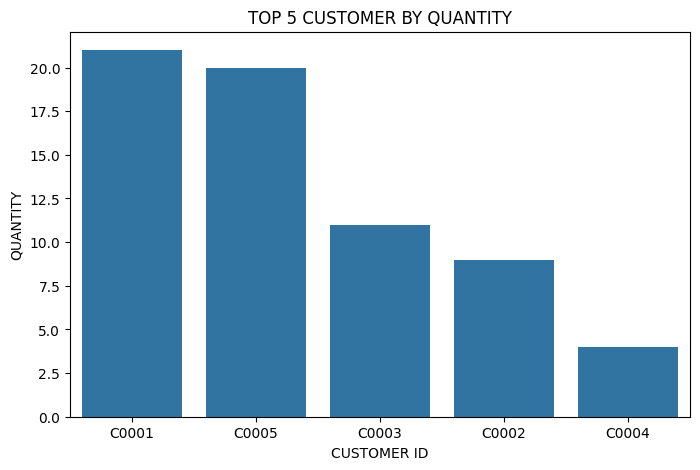

In [146]:
plt.figure(figsize=(8,5))
sns.barplot(x='customer_id',y='quantity',data=top_5_customer)
plt.title('TOP 5 CUSTOMER BY QUANTITY')
plt.xlabel('CUSTOMER ID')
plt.ylabel('QUANTITY')

Customer whose id is C0001, purchase most quantity of the product

#### 8) Conclusion